In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\GFD LAB\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df=pd.read_csv(r"C:\Users\acann\OneDrive\Desktop\mtech major project\Anwesha Chakraborty\output\Final_Dataset.csv")

In [4]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [5]:
print(df.shape)
print(df.head())
print(df.dtypes)

(21687, 7)
             Datetime  PM2.5_Mean  Visibility     RH  Temperature  WindSpeed  \
0 2024-01-01 00:00:00  170.053667    1207.008  87.56         12.0   2.056384   
1 2024-01-01 01:00:00  169.284333    1207.008  87.47         11.0   0.000000   
2 2024-01-01 02:00:00  165.553000    1207.008  87.47         11.0   2.056384   
3 2024-01-01 03:00:00  163.278667    1207.008  87.47         11.0   1.542288   
4 2024-01-01 04:00:00  155.996000    1207.008  87.47         11.0   1.542288   

          BLH  
0   39.382355  
1   47.932030  
2   57.352417  
3   62.579464  
4  135.569460  
Datetime       datetime64[ns]
PM2.5_Mean            float64
Visibility            float64
RH                    float64
Temperature           float64
WindSpeed             float64
BLH                   float64
dtype: object


In [6]:
print(df.isnull().sum())

Datetime       0
PM2.5_Mean     0
Visibility     0
RH             0
Temperature    0
WindSpeed      0
BLH            0
dtype: int64


In [7]:
features = [
    "PM2.5_Mean",
    "RH",
    "Temperature",
    "WindSpeed",
    "BLH"
]

target = "Visibility"

In [8]:
seasonal_months=[1,2,3,11,12]

In [9]:
train_case1 = df[
    (df["Datetime"].dt.year.isin([2024, 2025])) &
    (df["Datetime"].dt.month.isin(seasonal_months))
].copy()

In [10]:
test_case1 = df[
    (df["Datetime"].dt.year == 2026) &
    (df["Datetime"].dt.month.isin([1, 2, 3]))
].copy()

In [11]:
print("Case 1 training:", train_case1.shape)
print("Case 1 testing:", test_case1.shape)

print("\nTraining period:")
print(train_case1["Datetime"].min(), "to", train_case1["Datetime"].max())

print("\nTesting period:")
print(test_case1["Datetime"].min(), "to", test_case1["Datetime"].max())

Case 1 training: (7201, 7)
Case 1 testing: (2156, 7)

Training period:
2024-01-01 00:00:00 to 2025-12-31 23:00:00

Testing period:
2026-01-01 00:00:00 to 2026-03-31 23:00:00


In [12]:
X_train = train_case1[features]
y_train = train_case1[target]

X_test = test_case1[features]
y_test = test_case1[target]

In [13]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7201, 5)
y_train: (7201,)
X_test: (2156, 5)
y_test: (2156,)


In [14]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = model_lr.predict(X_test)

In [16]:
results = pd.DataFrame({
    "Datetime": test_case1["Datetime"].values,
    "Actual_Visibility": y_test.values,
    "Predicted_Visibility": y_pred
})

print(results.head(20))

              Datetime  Actual_Visibility  Predicted_Visibility
0  2026-01-01 00:00:00          498.89664            539.082051
1  2026-01-01 01:00:00          498.89664            546.664541
2  2026-01-01 02:00:00          498.89664            781.304531
3  2026-01-01 03:00:00          595.45728            888.397569
4  2026-01-01 04:00:00          692.01792            932.020290
5  2026-01-01 05:00:00          804.67200           1201.873607
6  2026-01-01 06:00:00          997.79328           1468.570556
7  2026-01-01 07:00:00         1094.35392           1744.856734
8  2026-01-01 08:00:00         1094.35392           1763.062611
9  2026-01-01 09:00:00         1400.12928           1916.070150
10 2026-01-01 10:00:00         1496.68992           1703.186572
11 2026-01-01 11:00:00         1496.68992           1665.002011
12 2026-01-01 12:00:00         1207.00800           1261.544075
13 2026-01-01 13:00:00         1303.56864           1252.716281
14 2026-01-01 14:00:00         1400.1292

In [17]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Linear Regression - Case 1")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression - Case 1
MAE : 837.5658878094915
RMSE: 1017.7370735371975
R²  : 0.559079314542344


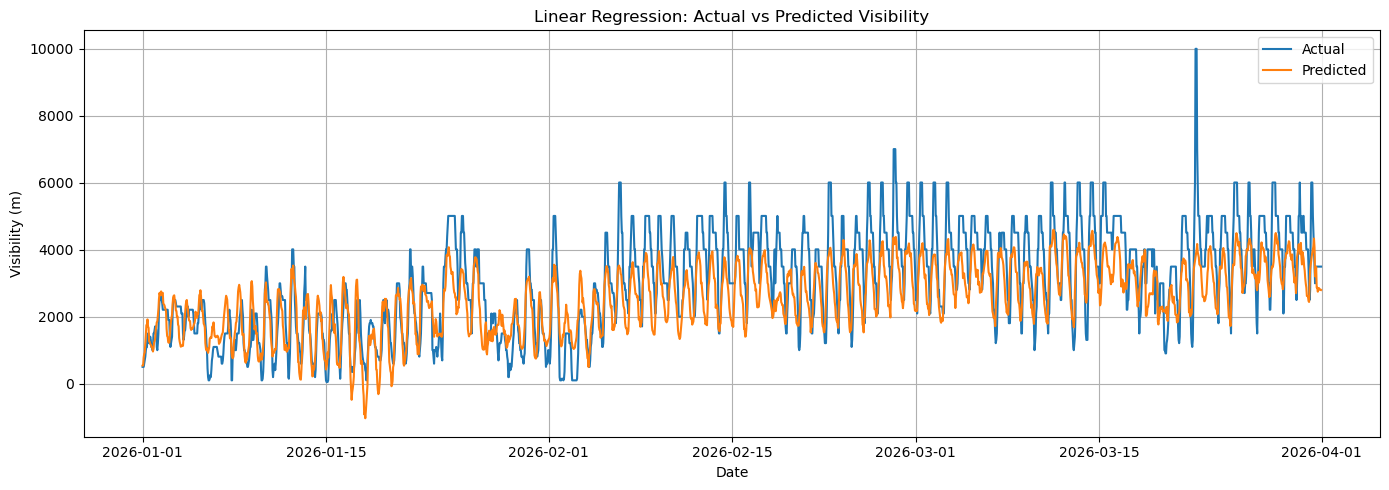

In [18]:
plt.figure(figsize=(14, 5))

plt.plot(
    results["Datetime"],
    results["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results["Datetime"],
    results["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title("Linear Regression: Actual vs Predicted Visibility")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

entire time period

In [19]:
train_case2 = df[
    (
        df["Datetime"].dt.year.isin([2024, 2025])
    ) |
    (
        (df["Datetime"].dt.year == 2026) &
        (df["Datetime"].dt.month.isin([4, 5, 6]))
    )
].copy()

test_case2 = df[
    (df["Datetime"].dt.year == 2026) &
    (df["Datetime"].dt.month.isin([1, 2, 3]))
].copy()

print("Case 2 training:", train_case2.shape)
print("Case 2 testing:", test_case2.shape)

print("\nTraining period:")
print(train_case2["Datetime"].min(), "to", train_case2["Datetime"].max())

print("\nTesting period:")
print(test_case2["Datetime"].min(), "to", test_case2["Datetime"].max())

Case 2 training: (19531, 7)
Case 2 testing: (2156, 7)

Training period:
2024-01-01 00:00:00 to 2026-06-29 23:00:00

Testing period:
2026-01-01 00:00:00 to 2026-03-31 23:00:00


In [20]:
X_train_case2 = train_case2[features]
y_train_case2 = train_case2[target]

X_test_case2 = test_case2[features]
y_test_case2 = test_case2[target]

print("X_train:", X_train_case2.shape)
print("y_train:", y_train_case2.shape)

print("X_test:", X_test_case2.shape)
print("y_test:", y_test_case2.shape)

X_train: (19531, 5)
y_train: (19531,)
X_test: (2156, 5)
y_test: (2156,)


In [21]:
model_lr_case2 = LinearRegression()

model_lr_case2.fit(
    X_train_case2,
    y_train_case2
)

LinearRegression()

In [22]:
y_pred_case2 = model_lr_case2.predict(X_test_case2)

In [23]:
results_case2 = pd.DataFrame({
    "Datetime": test_case2["Datetime"].values,
    "Actual_Visibility": y_test_case2.values,
    "Predicted_Visibility": y_pred_case2
})

print(results_case2.head(20))

              Datetime  Actual_Visibility  Predicted_Visibility
0  2026-01-01 00:00:00          498.89664            643.839576
1  2026-01-01 01:00:00          498.89664            649.542576
2  2026-01-01 02:00:00          498.89664            945.178015
3  2026-01-01 03:00:00          595.45728           1059.924580
4  2026-01-01 04:00:00          692.01792           1122.539745
5  2026-01-01 05:00:00          804.67200           1377.209428
6  2026-01-01 06:00:00          997.79328           1587.181150
7  2026-01-01 07:00:00         1094.35392           1853.895198
8  2026-01-01 08:00:00         1094.35392           1939.138363
9  2026-01-01 09:00:00         1400.12928           2038.063897
10 2026-01-01 10:00:00         1496.68992           1797.611366
11 2026-01-01 11:00:00         1496.68992           1694.352691
12 2026-01-01 12:00:00         1207.00800           1384.648225
13 2026-01-01 13:00:00         1303.56864           1335.408859
14 2026-01-01 14:00:00         1400.1292

In [24]:
mae_case2 = mean_absolute_error(
    y_test_case2,
    y_pred_case2
)

rmse_case2 = np.sqrt(
    mean_squared_error(
        y_test_case2,
        y_pred_case2
    )
)

r2_case2 = r2_score(
    y_test_case2,
    y_pred_case2
)

print("Linear Regression - Case 2")
print("MAE :", mae_case2)
print("RMSE:", rmse_case2)
print("R²  :", r2_case2)

Linear Regression - Case 2
MAE : 823.9351471649209
RMSE: 992.6643331576502
R²  : 0.5805365549462904


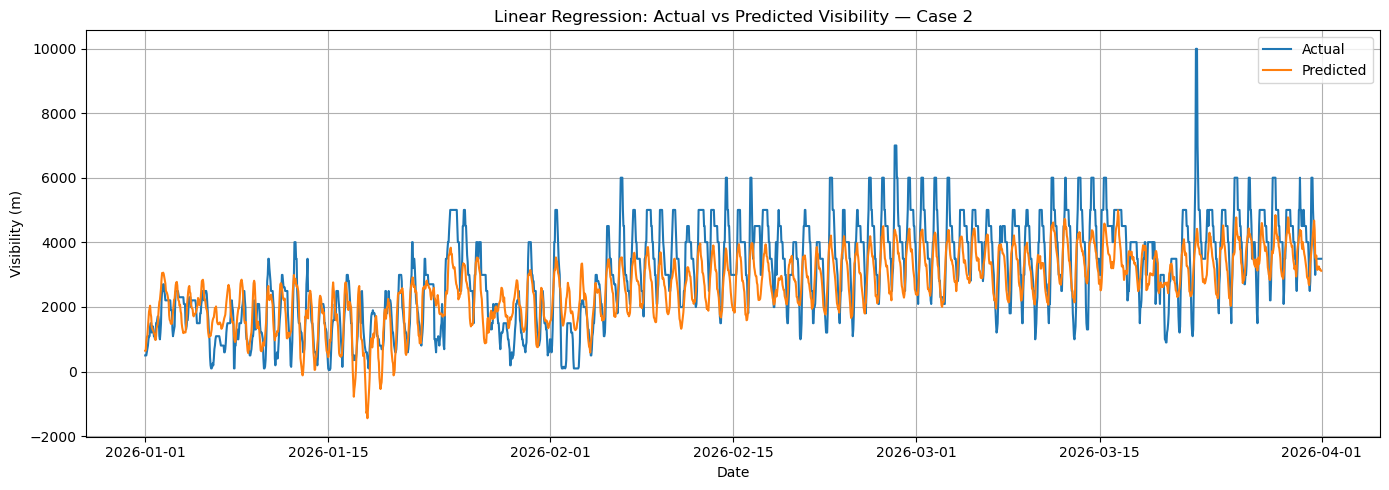

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(
    results_case2["Datetime"],
    results_case2["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results_case2["Datetime"],
    results_case2["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title("Linear Regression: Actual vs Predicted Visibility — Case 2")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Ridge Regression

In [26]:
from sklearn.linear_model import Ridge

In [27]:
ridge_case1=Ridge(alpha=1.0)
ridge_case1.fit(X_train, y_train)
y_pred_ridge_case1 = ridge_case1.predict(X_test)

In [28]:
mae_ridge_case1 = mean_absolute_error(
    y_test,
    y_pred_ridge_case1
)

rmse_ridge_case1 = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ridge_case1
    )
)

r2_ridge_case1 = r2_score(
    y_test,
    y_pred_ridge_case1
)

print("Ridge Regression - Case 1")
print("MAE :", mae_ridge_case1)
print("RMSE:", rmse_ridge_case1)
print("R²  :", r2_ridge_case1)

Ridge Regression - Case 1
MAE : 837.5660738882933
RMSE: 1017.7372084988737
R²  : 0.5590791976017309


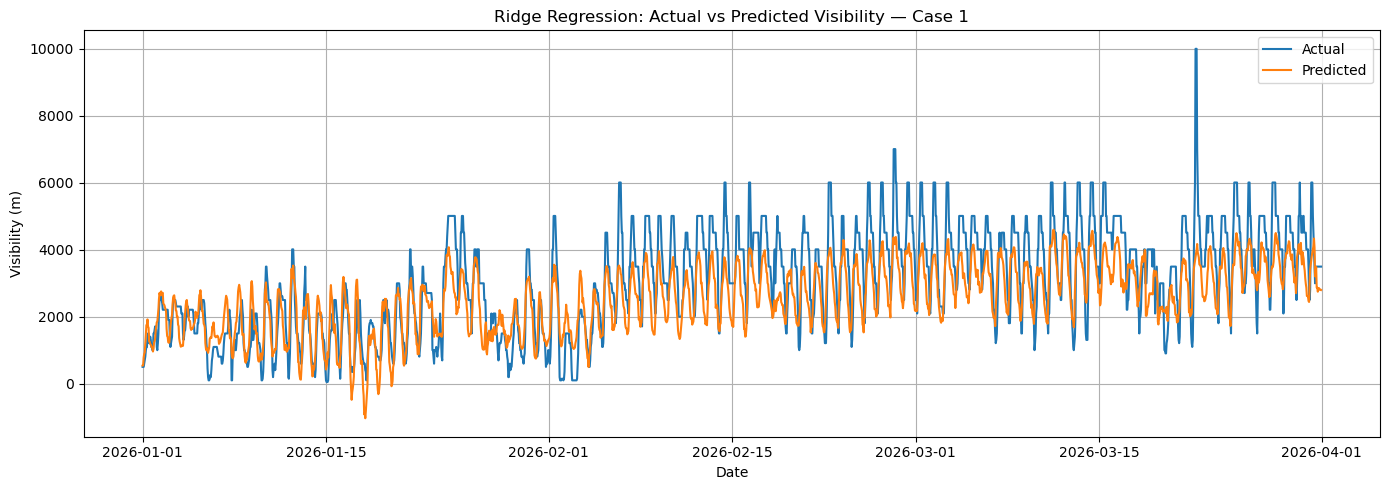

In [29]:
results_ridge_case1 = pd.DataFrame({
    "Datetime": test_case1["Datetime"].values,
    "Actual_Visibility": y_test.values,
    "Predicted_Visibility": y_pred_ridge_case1
})

plt.figure(figsize=(14, 5))

plt.plot(
    results_ridge_case1["Datetime"],
    results_ridge_case1["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results_ridge_case1["Datetime"],
    results_ridge_case1["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title("Ridge Regression: Actual vs Predicted Visibility — Case 1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [30]:
ridge_case2 = Ridge(alpha=1.0)

ridge_case2.fit(
    X_train_case2,
    y_train_case2
)

y_pred_ridge_case2 = ridge_case2.predict(X_test_case2)

In [31]:
mae_ridge_case2 = mean_absolute_error(
    y_test_case2,
    y_pred_ridge_case2
)

rmse_ridge_case2 = np.sqrt(
    mean_squared_error(
        y_test_case2,
        y_pred_ridge_case2
    )
)

r2_ridge_case2 = r2_score(
    y_test_case2,
    y_pred_ridge_case2
)

print("Ridge Regression - Case 2")
print("MAE :", mae_ridge_case2)
print("RMSE:", rmse_ridge_case2)
print("R²  :", r2_ridge_case2)

Ridge Regression - Case 2
MAE : 823.9350557507784
RMSE: 992.664228552528
R²  : 0.580536643350842


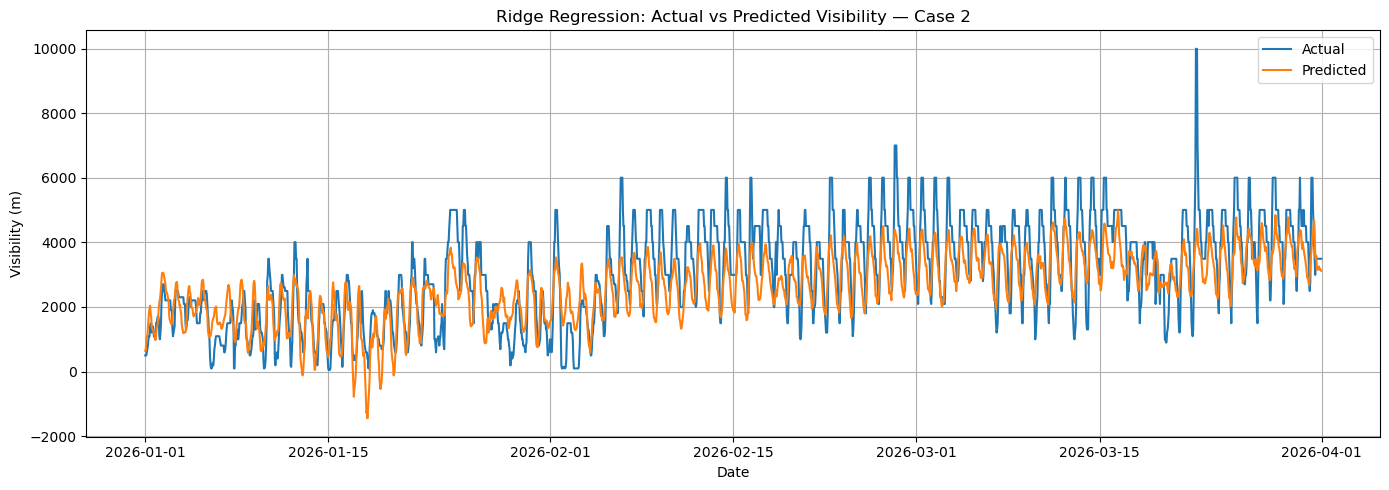

In [32]:
results_ridge_case2 = pd.DataFrame({
    "Datetime": test_case2["Datetime"].values,
    "Actual_Visibility": y_test_case2.values,
    "Predicted_Visibility": y_pred_ridge_case2
})

plt.figure(figsize=(14, 5))

plt.plot(
    results_ridge_case2["Datetime"],
    results_ridge_case2["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results_ridge_case2["Datetime"],
    results_ridge_case2["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title("Ridge Regression: Actual vs Predicted Visibility — Case 2")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [34]:
ridge_scaled_case1 = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10))
])

ridge_scaled_case1.fit(X_train, y_train)

y_pred_ridge_scaled_case1 = ridge_scaled_case1.predict(X_test)

In [35]:
mae_ridge_scaled_case1 = mean_absolute_error(
    y_test,
    y_pred_ridge_scaled_case1
)

rmse_ridge_scaled_case1 = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ridge_scaled_case1
    )
)

r2_ridge_scaled_case1 = r2_score(
    y_test,
    y_pred_ridge_scaled_case1
)

print("Scaled Ridge Regression - Case 1 (alpha=10)")
print("MAE :", mae_ridge_scaled_case1)
print("RMSE:", rmse_ridge_scaled_case1)
print("R²  :", r2_ridge_scaled_case1)

Scaled Ridge Regression - Case 1 (alpha=10)
MAE : 837.5159684014203
RMSE: 1017.6438965116332
R²  : 0.5591600461937283


In [36]:
ridge_scaled_case2 = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10))
])

ridge_scaled_case2.fit(
    X_train_case2,
    y_train_case2
)

y_pred_ridge_scaled_case2 = ridge_scaled_case2.predict(
    X_test_case2
)

In [37]:
mae_ridge_scaled_case2 = mean_absolute_error(
    y_test_case2,
    y_pred_ridge_scaled_case2
)

rmse_ridge_scaled_case2 = np.sqrt(
    mean_squared_error(
        y_test_case2,
        y_pred_ridge_scaled_case2
    )
)

r2_ridge_scaled_case2 = r2_score(
    y_test_case2,
    y_pred_ridge_scaled_case2
)

print("Scaled Ridge Regression - Case 2 (alpha=10)")
print("MAE :", mae_ridge_scaled_case2)
print("RMSE:", rmse_ridge_scaled_case2)
print("R²  :", r2_ridge_scaled_case2)

Scaled Ridge Regression - Case 2 (alpha=10)
MAE : 824.0100631601052
RMSE: 992.7483198054906
R²  : 0.5804655726055453


In [38]:
from sklearn.ensemble import RandomForestRegressor

In [39]:
rf_case1 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_case1.fit(X_train, y_train)

y_pred_rf_case1 = rf_case1.predict(X_test)

In [40]:
mae_rf_case1 = mean_absolute_error(
    y_test,
    y_pred_rf_case1
)

rmse_rf_case1 = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf_case1
    )
)

r2_rf_case1 = r2_score(
    y_test,
    y_pred_rf_case1
)

print("Random Forest Regression - Case 1")
print("MAE :", mae_rf_case1)
print("RMSE:", rmse_rf_case1)
print("R²  :", r2_rf_case1)

Random Forest Regression - Case 1
MAE : 736.0315003102036
RMSE: 926.2624946334655
R²  : 0.6347775693043105


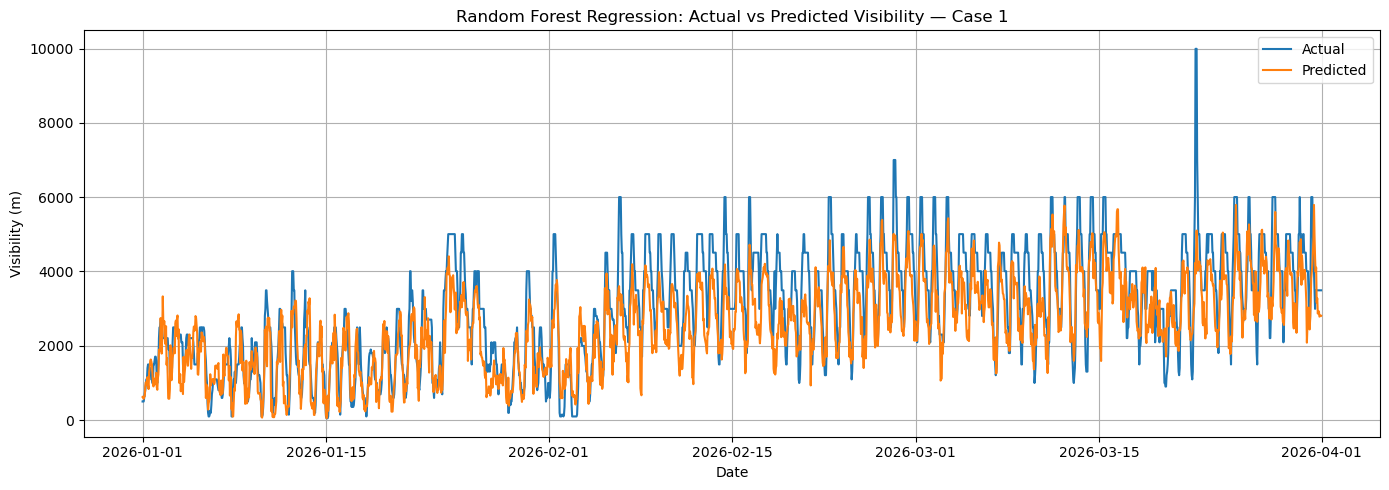

In [41]:
results_rf_case1 = pd.DataFrame({
    "Datetime": test_case1["Datetime"].values,
    "Actual_Visibility": y_test.values,
    "Predicted_Visibility": y_pred_rf_case1
})

plt.figure(figsize=(14, 5))

plt.plot(
    results_rf_case1["Datetime"],
    results_rf_case1["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results_rf_case1["Datetime"],
    results_rf_case1["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title("Random Forest Regression: Actual vs Predicted Visibility — Case 1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [42]:
rf_case2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_case2.fit(
    X_train_case2,
    y_train_case2
)

y_pred_rf_case2 = rf_case2.predict(
    X_test_case2
)

In [43]:
mae_rf_case2 = mean_absolute_error(
    y_test_case2,
    y_pred_rf_case2
)

rmse_rf_case2 = np.sqrt(
    mean_squared_error(
        y_test_case2,
        y_pred_rf_case2
    )
)

r2_rf_case2 = r2_score(
    y_test_case2,
    y_pred_rf_case2
)

print("Random Forest Regression - Case 2")
print("MAE :", mae_rf_case2)
print("RMSE:", rmse_rf_case2)
print("R²  :", r2_rf_case2)

Random Forest Regression - Case 2
MAE : 728.6780074775505
RMSE: 926.2634750662604
R²  : 0.634776796140677


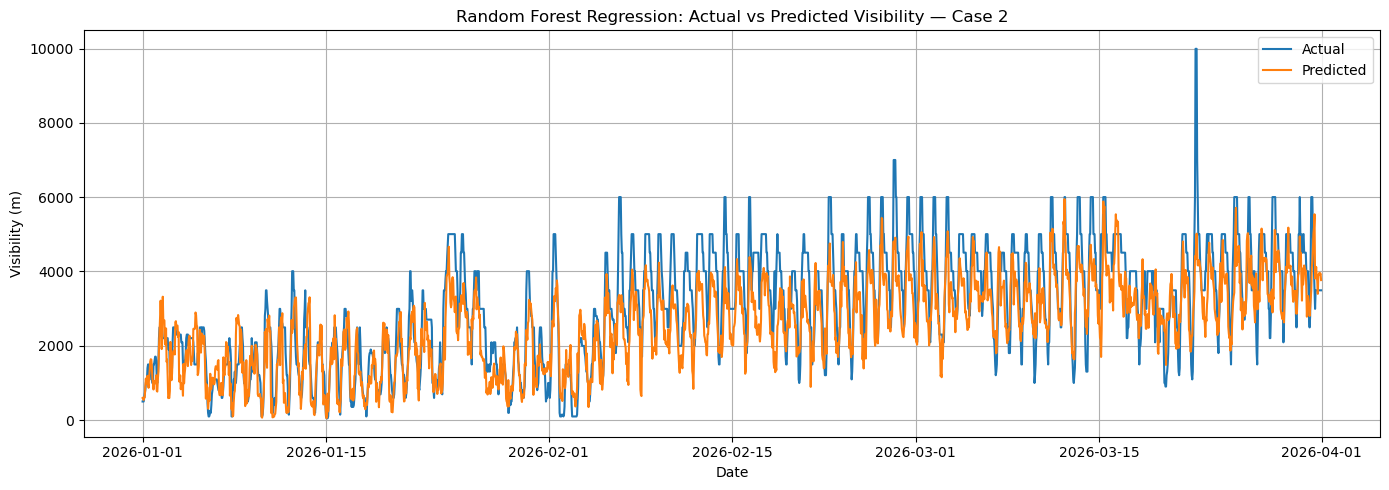

In [44]:
results_rf_case2 = pd.DataFrame({
    "Datetime": test_case2["Datetime"].values,
    "Actual_Visibility": y_test_case2.values,
    "Predicted_Visibility": y_pred_rf_case2
})

plt.figure(figsize=(14, 5))

plt.plot(
    results_rf_case2["Datetime"],
    results_rf_case2["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results_rf_case2["Datetime"],
    results_rf_case2["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title("Random Forest Regression: Actual vs Predicted Visibility — Case 2")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [46]:
X_train_rf1, X_val_rf1, y_train_rf1, y_val_rf1 = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [47]:
X_train_rf2, X_val_rf2, y_train_rf2, y_val_rf2 = train_test_split(
    X_train_case2,
    y_train_case2,
    test_size=0.2,
    random_state=42
)

In [48]:
param_grid = [
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1},
    
    {"n_estimators": 200, "max_depth": 10, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 20, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 30, "min_samples_leaf": 1},
    
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 2},
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 5},
    
    {"n_estimators": 300, "max_depth": 20, "min_samples_leaf": 2},
    {"n_estimators": 300, "max_depth": 30, "min_samples_leaf": 2}
]

In [49]:
tuning_results_rf1 = []

for params in param_grid:

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_rf1, y_train_rf1)

    val_pred = model.predict(X_val_rf1)

    mae = mean_absolute_error(y_val_rf1, val_pred)
    rmse = np.sqrt(mean_squared_error(y_val_rf1, val_pred))
    r2 = r2_score(y_val_rf1, val_pred)

    tuning_results_rf1.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [50]:
tuning_results_rf1 = pd.DataFrame(tuning_results_rf1)

tuning_results_rf1.sort_values(
    by="RMSE",
    ascending=True
)

,n_estimators,max_depth,min_samples_leaf,MAE,RMSE,R2
2,300,NaN,1,406.671959,553.923655,0.852001
0,100,NaN,1,407.660796,554.344551,0.851776
5,200,30.0,1,407.203954,554.350486,0.851773
1,200,NaN,1,407.200887,554.369314,0.851763
8,300,20.0,2,407.938546,554.826364,0.851518
4,200,20.0,1,407.729704,554.829025,0.851517
9,300,30.0,2,408.084608,555.107329,0.851368
6,200,NaN,2,408.562720,555.371815,0.851226
3,200,10.0,1,411.991440,556.883726,0.850415
7,200,NaN,5,415.926432,559.417396,0.849051


In [51]:
tuning_results_rf1.sort_values(
    by="MAE",
    ascending=True
)

,n_estimators,max_depth,min_samples_leaf,MAE,RMSE,R2
2,300,NaN,1,406.671959,553.923655,0.852001
1,200,NaN,1,407.200887,554.369314,0.851763
5,200,30.0,1,407.203954,554.350486,0.851773
0,100,NaN,1,407.660796,554.344551,0.851776
4,200,20.0,1,407.729704,554.829025,0.851517
8,300,20.0,2,407.938546,554.826364,0.851518
9,300,30.0,2,408.084608,555.107329,0.851368
6,200,NaN,2,408.562720,555.371815,0.851226
3,200,10.0,1,411.991440,556.883726,0.850415
7,200,NaN,5,415.926432,559.417396,0.849051


In [52]:
tuning_results_rf2 = []

for params in param_grid:

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_rf2, y_train_rf2)

    val_pred = model.predict(X_val_rf2)

    mae = mean_absolute_error(y_val_rf2, val_pred)
    rmse = np.sqrt(mean_squared_error(y_val_rf2, val_pred))
    r2 = r2_score(y_val_rf2, val_pred)

    tuning_results_rf2.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

In [53]:
tuning_results_rf2 = pd.DataFrame(tuning_results_rf2)

tuning_results_rf2.sort_values(
    by="RMSE",
    ascending=True
)

,n_estimators,max_depth,min_samples_leaf,MAE,RMSE,R2
3,200,10.0,1,490.741291,667.028517,0.778688
7,200,NaN,5,487.031431,669.138472,0.777286
8,300,20.0,2,484.449765,669.732237,0.776891
9,300,30.0,2,484.833086,669.991476,0.776718
6,200,NaN,2,485.000714,670.257864,0.776540
4,200,20.0,1,484.958894,670.483462,0.776390
2,300,NaN,1,485.548421,671.206490,0.775907
5,200,30.0,1,485.711968,671.756578,0.775540
1,200,NaN,1,486.123795,671.934027,0.775421
0,100,NaN,1,486.511035,674.377792,0.773785


In [54]:
best_params_rf1 = tuning_results_rf1.loc[
    tuning_results_rf1["RMSE"].idxmin()
]

print(best_params_rf1)

n_estimators        300.000000
max_depth                  NaN
min_samples_leaf      1.000000
MAE                 406.671959
RMSE                553.923655
R2                    0.852001
Name: 2, dtype: float64


In [55]:
best_params_rf2 = tuning_results_rf2.loc[
    tuning_results_rf2["RMSE"].idxmin()
]

print(best_params_rf2)

n_estimators        200.000000
max_depth            10.000000
min_samples_leaf      1.000000
MAE                 490.741291
RMSE                667.028517
R2                    0.778688
Name: 3, dtype: float64


In [56]:
rf_final_case1 = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_final_case1.fit(X_train, y_train)

y_pred_rf_final_case1 = rf_final_case1.predict(X_test)

In [57]:
mae_rf_final_case1 = mean_absolute_error(
    y_test,
    y_pred_rf_final_case1
)

rmse_rf_final_case1 = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf_final_case1
    )
)

r2_rf_final_case1 = r2_score(
    y_test,
    y_pred_rf_final_case1
)

print("Tuned Random Forest - Case 1")
print("MAE :", mae_rf_final_case1)
print("RMSE:", rmse_rf_final_case1)
print("R²  :", r2_rf_final_case1)

Tuned Random Forest - Case 1
MAE : 737.7194080653057
RMSE: 929.3563839525266
R²  : 0.6323336726362986


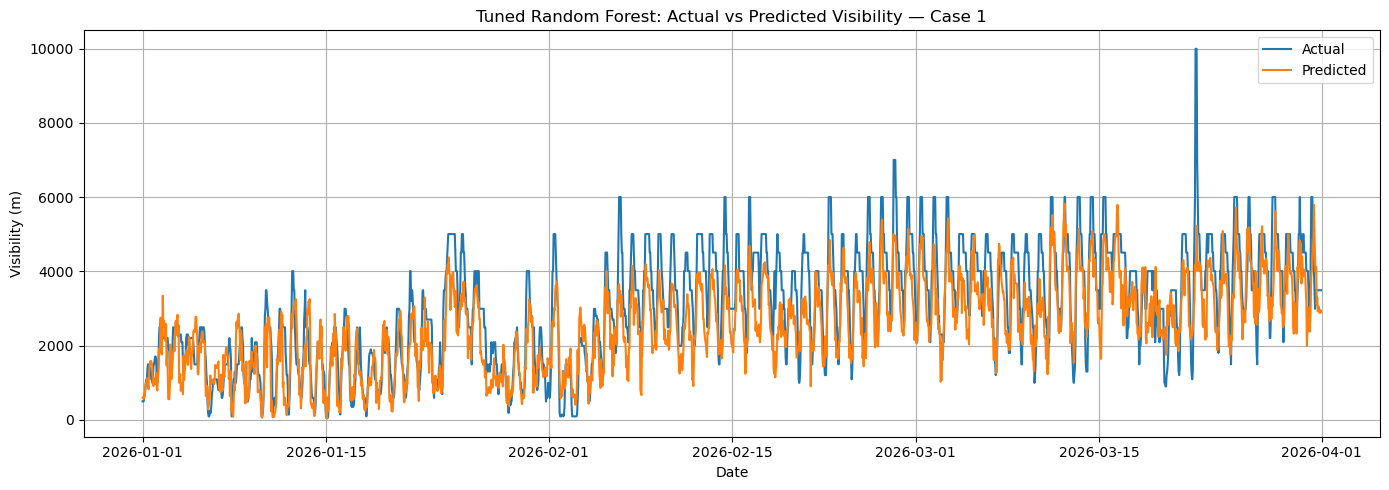

In [58]:
results_rf_final_case1 = pd.DataFrame({
    "Datetime": test_case1["Datetime"].values,
    "Actual_Visibility": y_test.values,
    "Predicted_Visibility": y_pred_rf_final_case1
})

plt.figure(figsize=(14, 5))

plt.plot(
    results_rf_final_case1["Datetime"],
    results_rf_final_case1["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results_rf_final_case1["Datetime"],
    results_rf_final_case1["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title("Tuned Random Forest: Actual vs Predicted Visibility — Case 1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [59]:
rf_final_case2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_final_case2.fit(
    X_train_case2,
    y_train_case2
)
y_pred_rf_final_case2 = rf_final_case2.predict(
    X_test_case2
)

In [60]:
mae_rf_final_case2 = mean_absolute_error(
    y_test_case2,
    y_pred_rf_final_case2
)

rmse_rf_final_case2 = np.sqrt(
    mean_squared_error(
        y_test_case2,
        y_pred_rf_final_case2
    )
)

r2_rf_final_case2 = r2_score(
    y_test_case2,
    y_pred_rf_final_case2
)

print("Tuned Random Forest - Case 2")
print("MAE :", mae_rf_final_case2)
print("RMSE:", rmse_rf_final_case2)
print("R²  :", r2_rf_final_case2)

Tuned Random Forest - Case 2
MAE : 724.3058449611348
RMSE: 914.9143305699134
R²  : 0.6436718409530127


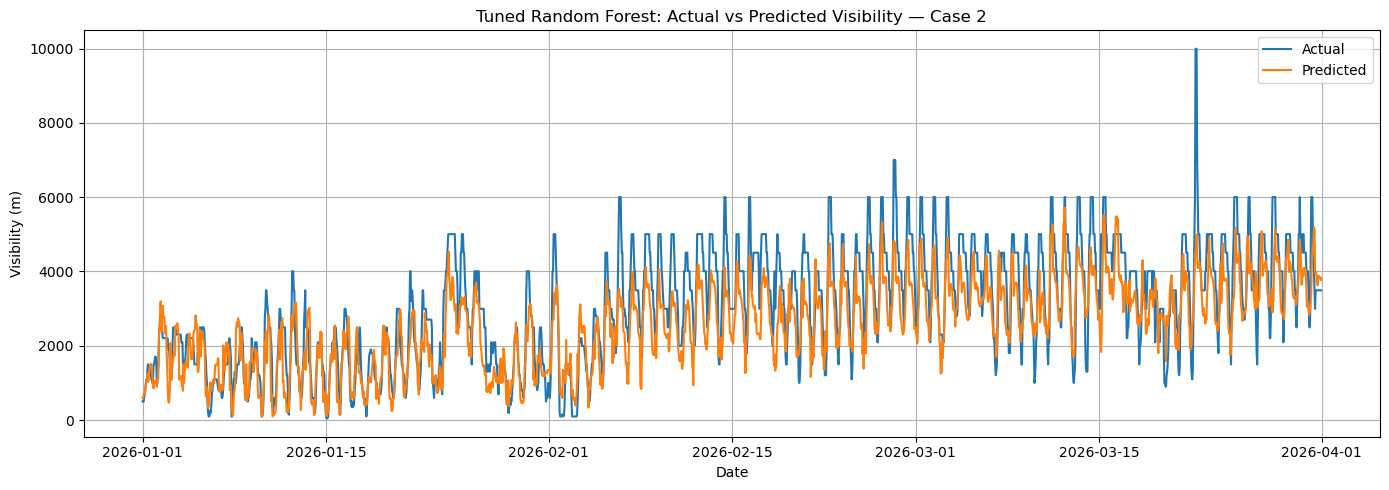

In [61]:
results_rf_final_case2 = pd.DataFrame({
    "Datetime": test_case2["Datetime"].values,
    "Actual_Visibility": y_test_case2.values,
    "Predicted_Visibility": y_pred_rf_final_case2
})

plt.figure(figsize=(14, 5))

plt.plot(
    results_rf_final_case2["Datetime"],
    results_rf_final_case2["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results_rf_final_case2["Datetime"],
    results_rf_final_case2["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title("Tuned Random Forest: Actual vs Predicted Visibility — Case 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [62]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df_winter = df[
    df["Datetime"].dt.month.isin([11, 12, 1, 2, 3])
].copy()

print(df_winter.shape)

(9357, 7)


In [63]:
corr_vars = [
    "PM2.5_Mean",
    "Visibility",
    "RH",
    "Temperature",
    "WindSpeed",
    "BLH"
]

corr_matrix_winter = df_winter[corr_vars].corr(method="pearson")

print(corr_matrix_winter)

             PM2.5_Mean  Visibility        RH  Temperature  WindSpeed  \
PM2.5_Mean     1.000000   -0.621618  0.294268    -0.262662  -0.221927   
Visibility    -0.621618    1.000000 -0.713021     0.646578   0.318222   
RH             0.294268   -0.713021  1.000000    -0.826105  -0.397841   
Temperature   -0.262662    0.646578 -0.826105     1.000000   0.346016   
WindSpeed     -0.221927    0.318222 -0.397841     0.346016   1.000000   
BLH           -0.033119    0.366154 -0.599516     0.593787   0.519457   

                  BLH  
PM2.5_Mean  -0.033119  
Visibility   0.366154  
RH          -0.599516  
Temperature  0.593787  
WindSpeed    0.519457  
BLH          1.000000  


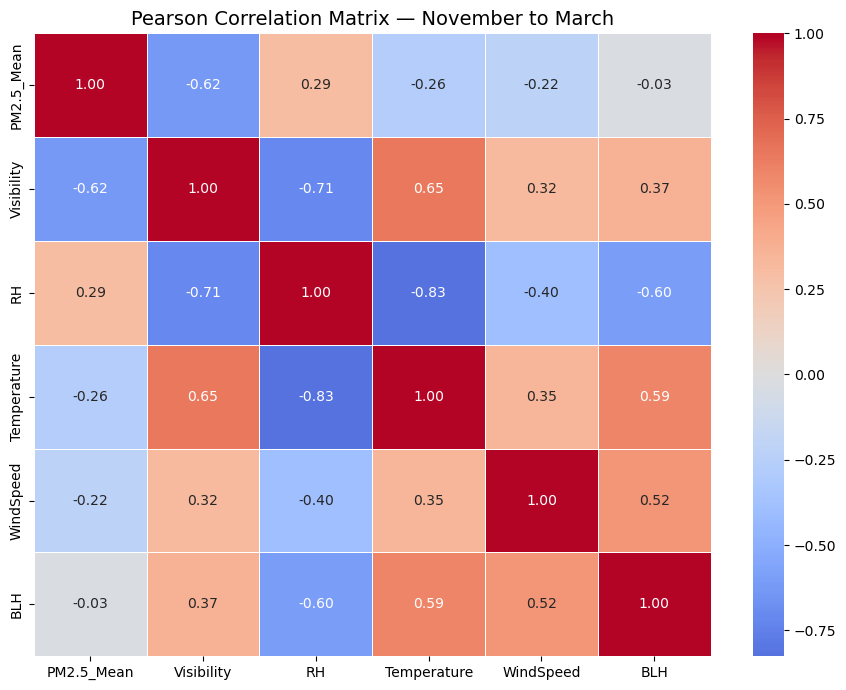

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix_winter,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Pearson Correlation Matrix — November to March",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [65]:
from sklearn.ensemble import GradientBoostingRegressor

In [66]:
gb_case1 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_case1.fit(X_train, y_train)

y_pred_gb_case1 = gb_case1.predict(X_test)

In [67]:
mae_gb_case1 = mean_absolute_error(
    y_test,
    y_pred_gb_case1
)

rmse_gb_case1 = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gb_case1
    )
)

r2_gb_case1 = r2_score(
    y_test,
    y_pred_gb_case1
)

print("Gradient Boosting Regression - Case 1")
print("MAE :", mae_gb_case1)
print("RMSE:", rmse_gb_case1)
print("R²  :", r2_gb_case1)

Gradient Boosting Regression - Case 1
MAE : 732.6004154354843
RMSE: 919.6633548626633
R²  : 0.6399630719744362


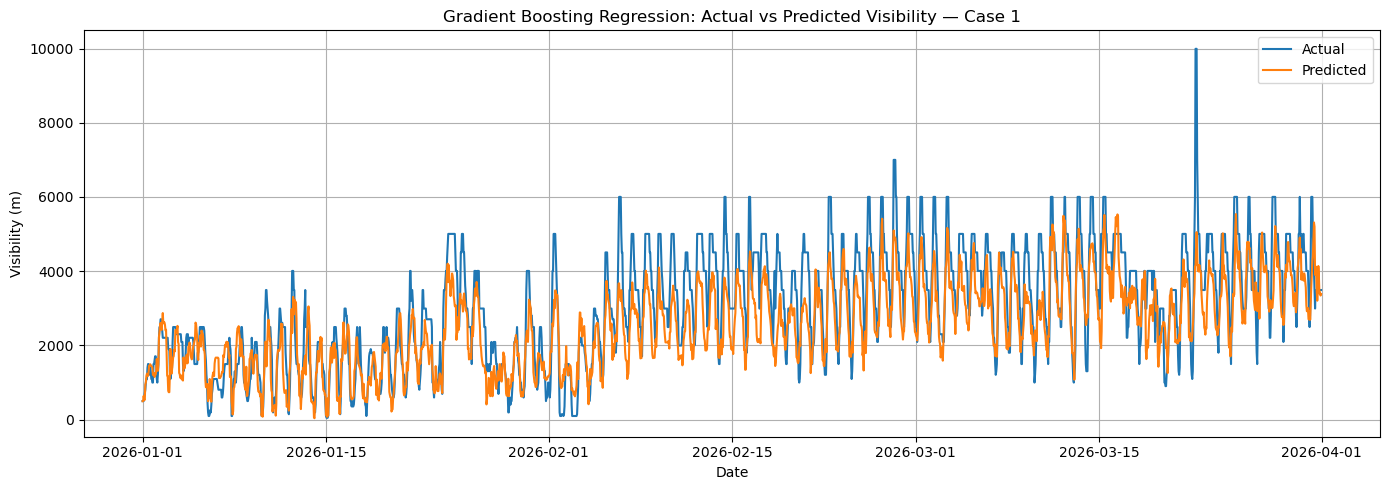

In [68]:
results_gb_case1 = pd.DataFrame({
    "Datetime": test_case1["Datetime"].values,
    "Actual_Visibility": y_test.values,
    "Predicted_Visibility": y_pred_gb_case1
})

plt.figure(figsize=(14, 5))

plt.plot(
    results_gb_case1["Datetime"],
    results_gb_case1["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results_gb_case1["Datetime"],
    results_gb_case1["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title(
    "Gradient Boosting Regression: Actual vs Predicted Visibility — Case 1"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [69]:
gb_case2 = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.06,
    max_depth=3,
    random_state=42
)

gb_case2.fit(
    X_train_case2,
    y_train_case2
)

y_pred_gb_case2 = gb_case2.predict(
    X_test_case2
)

In [70]:
mae_gb_case2 = mean_absolute_error(
    y_test_case2,
    y_pred_gb_case2
)

rmse_gb_case2 = np.sqrt(
    mean_squared_error(
        y_test_case2,
        y_pred_gb_case2
    )
)

r2_gb_case2 = r2_score(
    y_test_case2,
    y_pred_gb_case2
)

print("Gradient Boosting Regression - Case 2")
print("MAE :", mae_gb_case2)
print("RMSE:", rmse_gb_case2)
print("R²  :", r2_gb_case2)

Gradient Boosting Regression - Case 2
MAE : 721.2657441322757
RMSE: 912.3839441339405
R²  : 0.6456401150582254


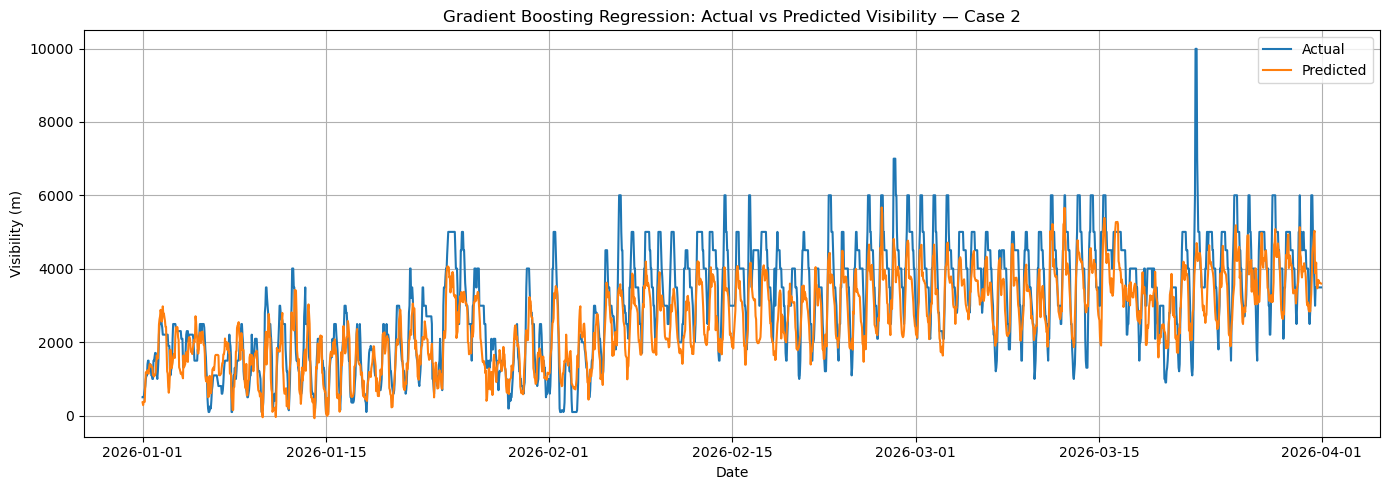

In [71]:
results_gb_case2 = pd.DataFrame({
    "Datetime": test_case2["Datetime"].values,
    "Actual_Visibility": y_test_case2.values,
    "Predicted_Visibility": y_pred_gb_case2
})

plt.figure(figsize=(14, 5))

plt.plot(
    results_gb_case2["Datetime"],
    results_gb_case2["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results_gb_case2["Datetime"],
    results_gb_case2["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title(
    "Gradient Boosting Regression: Actual vs Predicted Visibility — Case 2"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [72]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [73]:
svr_case1 = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=100,
        gamma="scale",
        epsilon=0.1
    ))
])

svr_case1.fit(
    X_train,
    y_train
)

y_pred_svr_case1 = svr_case1.predict(
    X_test
)

In [74]:
mae_svr_case1 = mean_absolute_error(
    y_test,
    y_pred_svr_case1
)

rmse_svr_case1 = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_svr_case1
    )
)

r2_svr_case1 = r2_score(
    y_test,
    y_pred_svr_case1
)

print("SVR - Case 1")
print("MAE :", mae_svr_case1)
print("RMSE:", rmse_svr_case1)
print("R²  :", r2_svr_case1)

SVR - Case 1
MAE : 713.931320323679
RMSE: 895.8240490112398
R²  : 0.6583867412693284


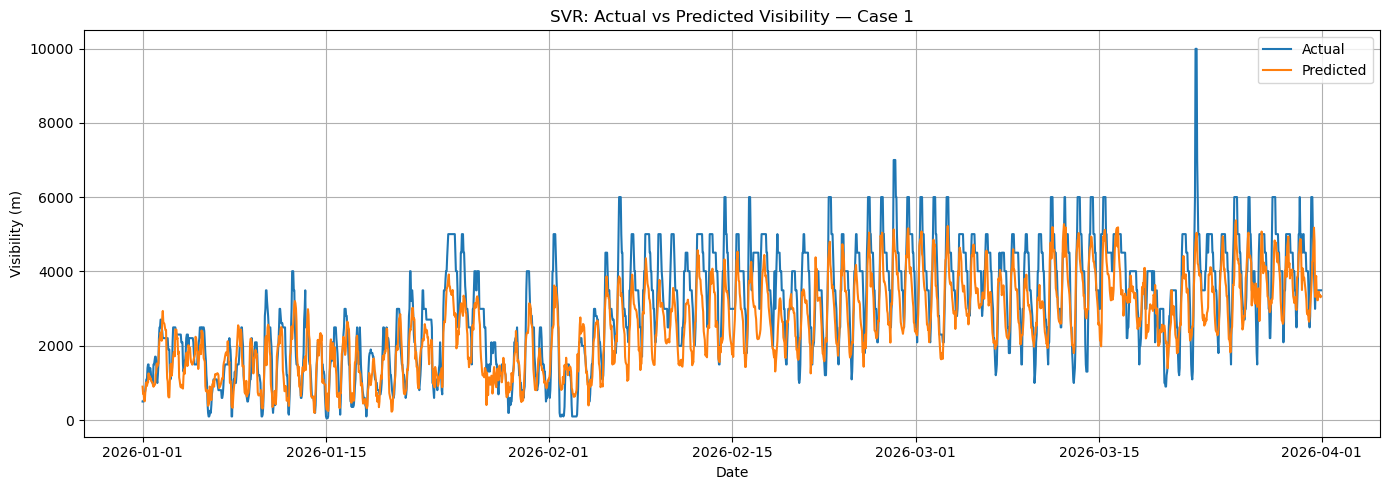

In [75]:
results_svr_case1 = pd.DataFrame({
    "Datetime": test_case1["Datetime"].values,
    "Actual_Visibility": y_test.values,
    "Predicted_Visibility": y_pred_svr_case1
})

plt.figure(figsize=(14, 5))

plt.plot(
    results_svr_case1["Datetime"],
    results_svr_case1["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results_svr_case1["Datetime"],
    results_svr_case1["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title("SVR: Actual vs Predicted Visibility — Case 1")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [76]:
svr_case2 = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=100,
        gamma="scale",
        epsilon=0.1
    ))
])

svr_case2.fit(
    X_train_case2,
    y_train_case2
)

y_pred_svr_case2 = svr_case2.predict(
    X_test_case2
)

In [77]:
mae_svr_case2 = mean_absolute_error(
    y_test_case2,
    y_pred_svr_case2
)

rmse_svr_case2 = np.sqrt(
    mean_squared_error(
        y_test_case2,
        y_pred_svr_case2
    )
)

r2_svr_case2 = r2_score(
    y_test_case2,
    y_pred_svr_case2
)

print("SVR - Case 2")
print("MAE :", mae_svr_case2)
print("RMSE:", rmse_svr_case2)
print("R²  :", r2_svr_case2)

SVR - Case 2
MAE : 706.7452717823987
RMSE: 897.2438210855128
R²  : 0.6573030523267536


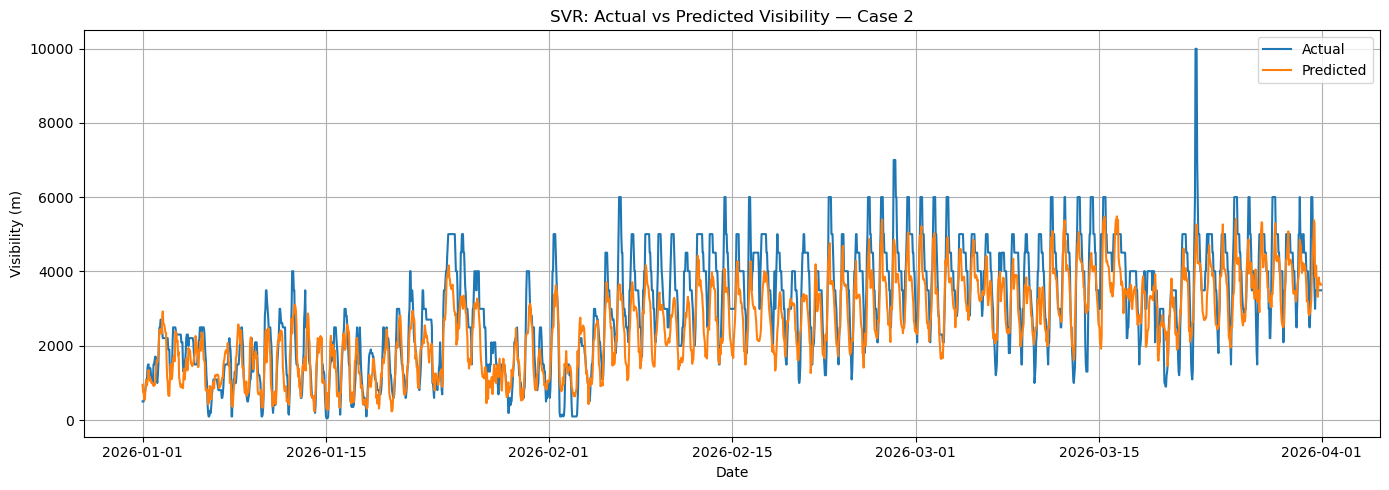

In [78]:
results_svr_case2 = pd.DataFrame({
    "Datetime": test_case2["Datetime"].values,
    "Actual_Visibility": y_test_case2.values,
    "Predicted_Visibility": y_pred_svr_case2
})

plt.figure(figsize=(14, 5))

plt.plot(
    results_svr_case2["Datetime"],
    results_svr_case2["Actual_Visibility"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    results_svr_case2["Datetime"],
    results_svr_case2["Predicted_Visibility"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Visibility (m)")
plt.title("SVR: Actual vs Predicted Visibility — Case 2")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [80]:
def evaluate_binary_fog(y_actual, y_predicted):

    # Convert to numpy arrays
    y_actual = np.asarray(y_actual)
    y_predicted = np.asarray(y_predicted)

    # Actual and predicted fog events
    actual_fog = (y_actual < 1000).astype(int)
    predicted_fog = (y_predicted < 1000).astype(int)

    # Confusion matrix
    cm = confusion_matrix(
        actual_fog,
        predicted_fog,
        labels=[0, 1]
    )

    # Extract values
    TN, FP, FN, TP = cm.ravel()

    # Metrics
    POD = TP / (TP + FN) if (TP + FN) > 0 else np.nan

    FAR = FP / (TP + FP) if (TP + FP) > 0 else np.nan

    CSI = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else np.nan

    precision = precision_score(
        actual_fog,
        predicted_fog,
        zero_division=0
    )

    recall = recall_score(
        actual_fog,
        predicted_fog,
        zero_division=0
    )

    f1 = f1_score(
        actual_fog,
        predicted_fog,
        zero_division=0
    )

    return {
        "TN": TN,
        "FP (False Alarms)": FP,
        "FN (Missed Fog)": FN,
        "TP (Correctly Captured)": TP,

        "Actual Fog Events": TP + FN,
        "Predicted Fog Events": TP + FP,

        "POD": POD,
        "FAR": FAR,
        "CSI": CSI,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [81]:
def classify_fog_category(visibility):

    visibility = np.asarray(visibility)

    categories = np.full(
        len(visibility),
        "No Fog",
        dtype=object
    )

    # Shallow Fog
    categories[
        (visibility >= 700) &
        (visibility < 1000)
    ] = "Shallow Fog"

    # Dense Fog
    categories[
        (visibility >= 350) &
        (visibility < 700)
    ] = "Dense Fog"

    # Very Dense Fog
    categories[
        visibility < 350
    ] = "Very Dense Fog"

    return categories

In [82]:
def evaluate_fog_categories(y_actual, y_predicted):

    labels = [
        "Shallow Fog",
        "Dense Fog",
        "Very Dense Fog"
    ]

    actual_categories = classify_fog_category(
        y_actual
    )

    predicted_categories = classify_fog_category(
        y_predicted
    )

    results = []

    for category in labels:

        actual_binary = (
            actual_categories == category
        ).astype(int)

        predicted_binary = (
            predicted_categories == category
        ).astype(int)

        # Actual number of events
        actual_events = actual_binary.sum()

        # Correctly captured events
        correctly_captured = np.sum(
            (actual_binary == 1) &
            (predicted_binary == 1)
        )

        # False alarms for this category
        false_alarms = np.sum(
            (actual_binary == 0) &
            (predicted_binary == 1)
        )

        # Missed events
        missed_events = np.sum(
            (actual_binary == 1) &
            (predicted_binary == 0)
        )

        precision = precision_score(
            actual_binary,
            predicted_binary,
            zero_division=0
        )

        recall = recall_score(
            actual_binary,
            predicted_binary,
            zero_division=0
        )

        f1 = f1_score(
            actual_binary,
            predicted_binary,
            zero_division=0
        )

        results.append({

            "Fog Category": category,

            "Actual Events": actual_events,

            "Correctly Captured": correctly_captured,

            "Missed Events": missed_events,

            "False Alarms": false_alarms,

            "Detection Rate": recall,

            "Precision": precision,

            "F1 Score": f1
        })

    return pd.DataFrame(results)

In [83]:
def plot_fog_category_matrix(
    y_actual,
    y_predicted,
    model_name,
    case_name,
    dataset_name
):

    labels = [
        "No Fog",
        "Shallow Fog",
        "Dense Fog",
        "Very Dense Fog"
    ]

    actual_categories = classify_fog_category(
        y_actual
    )

    predicted_categories = classify_fog_category(
        y_predicted
    )

    cm = confusion_matrix(
        actual_categories,
        predicted_categories,
        labels=labels
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        values_format="d",
        cmap="Blues",
        colorbar=False
    )

    plt.title(
        f"{dataset_name}\n"
        f"{model_name} - {case_name}\n"
        f"Fog Category Confusion Matrix"
    )

    plt.xlabel("Predicted Category")
    plt.ylabel("Actual Category")

    plt.tight_layout()
    plt.show()

In [84]:
all_predictions = {

    "Linear Regression - Case 1": (
        y_test,
        y_pred
    ),

    "Linear Regression - Case 2": (
        y_test_case2,
        y_pred_case2
    ),


    "Ridge Regression - Case 1": (
        y_test,
        y_pred_ridge_case1
    ),

    "Ridge Regression - Case 2": (
        y_test_case2,
        y_pred_ridge_case2
    ),


    "Random Forest - Case 1": (
        y_test,
        y_pred_rf_final_case1
    ),

    "Random Forest - Case 2": (
        y_test_case2,
        y_pred_rf_final_case2
    ),


    "Gradient Boosting - Case 1": (
        y_test,
        y_pred_gb_case1
    ),

    "Gradient Boosting - Case 2": (
        y_test_case2,
        y_pred_gb_case2
    ),


    "SVR - Case 1": (
        y_test,
        y_pred_svr_case1
    ),

    "SVR - Case 2": (
        y_test_case2,
        y_pred_svr_case2
    )
}

In [85]:
binary_results = []

for name, (y_actual, y_predicted) in all_predictions.items():

    metrics = evaluate_binary_fog(
        y_actual,
        y_predicted
    )

    metrics["Model / Case"] = name

    binary_results.append(metrics)


binary_results_df = pd.DataFrame(
    binary_results
)

# Put Model / Case first
binary_results_df = binary_results_df[
    [
        "Model / Case",
        "Actual Fog Events",
        "Predicted Fog Events",
        "TP (Correctly Captured)",
        "FN (Missed Fog)",
        "FP (False Alarms)",
        "TN",
        "POD",
        "FAR",
        "CSI",
        "Precision",
        "Recall",
        "F1 Score"
    ]
]

binary_results_df

,Model / Case,Actual Fog Events,Predicted Fog Events,TP (Correctly Captured),FN (Missed Fog),FP (False Alarms),TN,POD,FAR,CSI,Precision,Recall,F1 Score
0,Linear Regression - Case 1,233,136,97,136,39,1884,0.416309,0.286765,0.356618,0.713235,0.416309,0.525745
1,Linear Regression - Case 2,233,131,86,147,45,1878,0.369099,0.343511,0.309353,0.656489,0.369099,0.472527
2,Ridge Regression - Case 1,233,136,97,136,39,1884,0.416309,0.286765,0.356618,0.713235,0.416309,0.525745
3,Ridge Regression - Case 2,233,131,86,147,45,1878,0.369099,0.343511,0.309353,0.656489,0.369099,0.472527
4,Random Forest - Case 1,233,252,160,73,92,1831,0.686695,0.365079,0.492308,0.634921,0.686695,0.659794
5,Random Forest - Case 2,233,253,165,68,88,1835,0.708155,0.347826,0.514019,0.652174,0.708155,0.679012
6,Gradient Boosting - Case 1,233,203,145,88,58,1865,0.622318,0.285714,0.498282,0.714286,0.622318,0.665138
7,Gradient Boosting - Case 2,233,199,145,88,54,1869,0.622318,0.271357,0.505226,0.728643,0.622318,0.671296
8,SVR - Case 1,233,242,162,71,80,1843,0.695279,0.330579,0.517572,0.669421,0.695279,0.682105
9,SVR - Case 2,233,244,163,70,81,1842,0.699571,0.331967,0.519108,0.668033,0.699571,0.683438


In [88]:
all_category_results = []

for name, (y_actual, y_predicted) in all_predictions.items():

    category_results = evaluate_fog_categories(
        y_actual,
        y_predicted
    )

    category_results.insert(
        0,
        "Model / Case",
        name
    )

    all_category_results.append(
        category_results
    )


category_results_df = pd.concat(
    all_category_results,
    ignore_index=True
)

# Round the performance metrics
category_results_df[
    ["Detection Rate", "Precision", "F1 Score"]
] = category_results_df[
    ["Detection Rate", "Precision", "F1 Score"]
].round(4)

category_results_df

,Model / Case,Fog Category,Actual Events,Correctly Captured,Missed Events,False Alarms,Detection Rate,Precision,F1 Score
0,Linear Regression - Case 1,Shallow Fog,102,11,91,52,0.1078,0.1746,0.1333
1,Linear Regression - Case 1,Dense Fog,87,12,75,28,0.1379,0.3000,0.1890
2,Linear Regression - Case 1,Very Dense Fog,44,2,42,31,0.0455,0.0606,0.0519
3,Linear Regression - Case 2,Shallow Fog,102,10,92,41,0.0980,0.1961,0.1307
4,Linear Regression - Case 2,Dense Fog,87,15,72,28,0.1724,0.3488,0.2308
5,Linear Regression - Case 2,Very Dense Fog,44,2,42,35,0.0455,0.0541,0.0494
6,Ridge Regression - Case 1,Shallow Fog,102,11,91,52,0.1078,0.1746,0.1333
7,Ridge Regression - Case 1,Dense Fog,87,12,75,28,0.1379,0.3000,0.1890
8,Ridge Regression - Case 1,Very Dense Fog,44,2,42,31,0.0455,0.0606,0.0519
9,Ridge Regression - Case 2,Shallow Fog,102,10,92,41,0.0980,0.1961,0.1307


In [89]:
best_category_per_model = (
    category_results_df
    .loc[
        category_results_df.groupby("Model / Case")["F1 Score"].idxmax(),
        [
            "Model / Case",
            "Fog Category",
            "Actual Events",
            "Correctly Captured",
            "Detection Rate",
            "Precision",
            "F1 Score"
        ]
    ]
    .sort_values("Model / Case")
    .reset_index(drop=True)
)

best_category_per_model

,Model / Case,Fog Category,Actual Events,Correctly Captured,Detection Rate,Precision,F1 Score
0,Gradient Boosting - Case 1,Dense Fog,87,37,0.4253,0.4302,0.4277
1,Gradient Boosting - Case 2,Dense Fog,87,36,0.4138,0.4286,0.4211
2,Linear Regression - Case 1,Dense Fog,87,12,0.1379,0.3000,0.1890
3,Linear Regression - Case 2,Dense Fog,87,15,0.1724,0.3488,0.2308
4,Random Forest - Case 1,Dense Fog,87,37,0.4253,0.3524,0.3854
5,Random Forest - Case 2,Dense Fog,87,36,0.4138,0.3564,0.3830
6,Ridge Regression - Case 1,Dense Fog,87,12,0.1379,0.3000,0.1890
7,Ridge Regression - Case 2,Dense Fog,87,15,0.1724,0.3488,0.2308
8,SVR - Case 1,Dense Fog,87,35,0.4023,0.4023,0.4023
9,SVR - Case 2,Dense Fog,87,33,0.3793,0.3837,0.3815


In [94]:
def evaluate_fog_bias(y_actual, y_predicted):

    actual = np.asarray(y_actual)
    predicted = np.asarray(y_predicted)

    # Only consider actual fog observations
    mask = actual < 1000

    actual = actual[mask]
    predicted = predicted[mask]

    # Direct visibility bias
    bias = np.mean(predicted - actual)

    if bias > 0:
        tendency = "Underestimates fog severity"
    elif bias < 0:
        tendency = "Overestimates fog severity"
    else:
        tendency = "No overall bias"

    return {
        "Mean Visibility Bias (m)": bias,
        "Fog Severity Tendency": tendency
    }
    

In [96]:
fog_bias_results = []

for name, (y_actual, y_predicted) in all_predictions.items():

    result = evaluate_fog_bias(
        y_actual,
        y_predicted
    )

    result["Model / Case"] = name

    fog_bias_results.append(result)


fog_bias_df = pd.DataFrame(fog_bias_results)

fog_bias_df = fog_bias_df[
    [
        "Model / Case",
        "Mean Visibility Bias (m)",
        "Fog Severity Tendency"
    ]
]

fog_bias_df

,Model / Case,Mean Visibility Bias (m),Fog Severity Tendency
0,Linear Regression - Case 1,385.839099,Underestimates fog severity
1,Linear Regression - Case 2,501.555130,Underestimates fog severity
2,Ridge Regression - Case 1,385.840605,Underestimates fog severity
3,Ridge Regression - Case 2,501.555500,Underestimates fog severity
4,Random Forest - Case 1,188.855482,Underestimates fog severity
5,Random Forest - Case 2,200.237207,Underestimates fog severity
6,Gradient Boosting - Case 1,258.840247,Underestimates fog severity
7,Gradient Boosting - Case 2,246.813197,Underestimates fog severity
8,SVR - Case 1,241.229640,Underestimates fog severity
9,SVR - Case 2,248.379166,Underestimates fog severity
